## Rubric

Instructions: DELETE this cell before you submit via a `git push` to your repo before deadline. This cell is for your reference only and is not needed in your report. 

 Scoring: Out of 10 points

- Each Developing  => -2 pts
- Each Unsatisfactory/Missing => -4 pts
  - until the score is 0

If students address the detailed feedback in a future checkpoint they will earn these points back






|                                  | **Unsatisfactory**                                                                                                                                                                                                                                                                                                                        | **Developing**                                                                                                                                                                                                       | **Proficient**                                                                                                                                                                                            | **Excellent**                                                                                                                                                                            |
|----------------------------------|---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **EDA relevance**                | EDA is mostly neither relevant to the question nor helpful in figuring out how to address the question. Or the EDA does address the question, but many obviously relevant variables / analyses / figures were not included. | EDA is partly irrelevant/unhelpful. EDA missed one or two obvioulsy relevant analysis (distributions of single variables or relationships between variables) | EDA includes the obviously relevant / helpful variables in addressing the question.                                                              | Thorough EDA fully explored the dataset                                                                                                                 |
| **EDA analysis and description** | Many of the analyses are poor choices (e.g., using means instead of medians for obviously skewed data), or are poorly described in the text, or do not aid understanding the data                                                                                                                                                     | Some of the analyses are poor choices, or are poorly described in the text, or do not aid understanding the data                                                                                                 | All analyses are correct choices. Only one or two have minor issues in the text descriptions supporting them. Mostly they fit well with other elements of the EDA and support understanding the data  | All analyses are correct choices with clear text descriptions supporting them. The figures fit well with the other elements of the EDA, producing a clear understanding of the data. |
| **EDA figures**                  | Many of the figures are poor plot choices (e.g., using a bar plot to represent a time series where it would be better to use a line plot) or have poor aesthetics (including colormap, data point shape/color, axis labels, titles, annotations, text legibility) or do not aid understanding the data                                | Some of the figures are poor plot choices or have poor aesthetics. Some figures do not aid understanding the data                                                                                                | All figures are correct plot choices. Only one or two have minor questionable aesthetic choices. The figures mostly fit well with the other elements of the EDA and support understanding the data    | All figures are correct plot choices with beautiful aesthetics. The figures fit well with the other elements of the EDA, producing a clear understanding of the data.                |





# COGS 108 - EDA Checkpoint

## Authors

Instructions: REPLACE the contents of this cell with your team list and their contributions. Note that this will change over the course of the checkpoints

This is a modified [CRediT taxonomy of contributions](https://credit.niso.org). For each group member please list how they contributed to this project using these terms:
> Analysis, Background research, Conceptualization, Data curation, Experimental investigation, Methodology, Project administration, Software, Visualization, Writing – original draft, Writing – review & editing

Example team list and credits:
- Alice Anderson: Conceptualization, Data curation, Methodology, Writing - original draft
- Bob Barker:  Analysis, Software, Visualization
- Charlie Chang: Project administration, Software, Writing - review & editing
- Dani Delgado: Analysis, Background research, Visualization, Writing - original draft

# Research Question

Does a decline of 50% or more in average monthly players within the first 12 months after a game’s peak significantly predict whether a Steam game will experience a sustained collapse in player engagement, defined as falling to 5% of its peak concurrent players, within the following 24 months?



## Background and Prior Work

Online multiplayer games depend on continued player engagements to justify the ongoing costs of server infrastructure, moderation, live updates and development support. These games require an active player base, and while engagement declines, companies must decide whether maintaining servers will be worth the commitment and resources used. There is yet to be a standardized, data driven benchmark that defines when a game has reached the point of sustained collapse. As a result, the threshold at which a game is considered no longer viable remains unclear. The lack of transparency creates uncertainty for players who are investing time and money without knowing how stable the game’s future truly is. 

Companies commonly consider several measurable factors when seeing whether to continue supporting certain titles. These can include concurrent player counts, monthly active users, retention rates, and the cost of maintaining development relative to revenue. Among these observable traits, player count is the most visible and consistently available metric, especially on platforms such as Steam. By tracking peaks and declines in concurrent players over time and often identify sharp falloffs following launch periods or major updates. In several live service cases, including MultiVersus, there is a noticeable pattern of an early peak followed by a rapid drop in players. While some decline after launch is expected, it is unclear at what point that decline signals long term collapse rather than normal market stabilization.

Existing research has approached this issue by modeling player retention and churn instead of defining a concrete collapse threshold. In Improved Retention Analysis in Freemium Role Playing Games by Jointly Modelling Players’ Motivation, Progression and Churn, the authors show that declining progression and reduced engagement are strong indicators that players are likely to stop playing altogether. Similarly, A Data Imputation Strategy to Enhance Online Game Churn Prediction, Considering Non Login Periods demonstrates that extended inactivity is a reliable predictor of permanent disengagement when properly modeled. These studies establish that measurable declines in engagement precede churn at the individual level. However, they do not define a population level benchmark that signals when a game as a whole is likely to experience sustained collapse. This gap motivates the present study, which tests whether a substantial early decline in average monthly players can serve as a measurable predictor of long term engagement deterioration across Steam multiplayer games.

^ Lee, JaeHong, et al. “A Data Imputation Strategy to Enhance Online Game Churn Prediction, Considering Non-Login Periods.” MDPI, Multidisciplinary Digital Publishing Institute, 23 June 2025, www.mdpi.com/2306-5729/10/7/96.

^ Karmakar, Bikram, et al. “Improved retention analysis in freemium role-playing games by jointly modelling players’ motivation, progression and churn.” Journal of the Royal Statistical Society Series A: Statistics in Society, vol. 185, no. 1, 11 Aug. 2021, pp. 102–133, https://doi.org/10.1111/rssa.12730.


# Hypothesis


Relating to our research question, this study investigates whether an early and substantial decline in player activity predicts long-term collapse in Steam multiplayer games. We expect that Steam games which see a drop of 50% or more in average monthly players within the first 12 months after reaching their peak are far more likely to experience a sustained collapse in player engagement, defined as falling to 5% of their peak concurrent players, within the following 24 months, compared to games that do not show such an early decline.

## Data

### Data overview

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your data checkpoint feedback


In [1]:
# Run this code every time when you're actively developing modules in .py files.  It's not needed if you aren't making modules
#
## this code is necessary for making sure that any modules we load are updated here 
## when their source code .py files are modified

%load_ext autoreload
%autoreload 2

In [2]:
# Setup code -- Run only once after cloning!!! 
#
# this code downloads the data from its source to the `data/00-raw/` directory
# if the data hasn't updated you don't need to do this again!

# if you don't already have these packages (you should!) uncomment this line
# %pip install requests tqdm

import sys
sys.path.append('./modules') # this tells python where to look for modules to import

import get_data # this is where we get the function we need to download data

# replace the urls and filenames in this list with your actual datafiles
# yes you can use Google drive share links or whatever
# format is a list of dictionaries; 
# each dict has keys of 
#   'url' where the resource is located
#   'filename' for the local filename where it will be stored 
datafiles = [
    { 'url': 'https://drive.google.com/uc?id=14-RTZD1GOc_JKGs32btNxfLe4bZ9WTOw', 'filename':'steamcharts.csv'}]

get_data.get_raw(datafiles,destination_directory='data/00-raw/')

Overall Download Progress: 100%|██████████| 1/1 [00:03<00:00,  3.22s/it]         

Successfully downloaded: steamcharts.csv


### Dataset #1 

Instructions: REPLACE the contents of this cell and the one below with your work, including any updates to recover points lost in your data checkpoint feedback

In [3]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 
import pandas as pd 
import seaborn as sns 
import numpy as np
from pathlib import Path

#Load the dataframe from previous checkpoint
df_clean = pd.read_csv('data/02-processed/steamcharts.csv') 




### Dataset #2
 as above, add any more copies of this that you need to given how many datasets you have

In [4]:
## YOUR CODE TO LOAD/CLEAN/TIDY/WRANGLE THE DATA GOES HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION 

## Results

### Exploratory Data Analysis

Instructions: replace the words in this subsection with whatever words you need to setup and preview the EDA you're going to do.   

Please explicitly load the fully wrangled data you will use from `data/02-processed`.  This is a good idea rather than forcing people to re-run the data getting / wrangling cells above.  Sometimes it takes a long time to get / wrangle data compared to reloading the fixed up dataset.

Carry out whatever EDA you need to for your project in the code cells below.  Because every project will be different we can't really give you much of a template at this point. But please make sure you describe the what and why in text here as well as providing interpretation of results and context.

Please note that you should consider the use of python modules in your work.  Any code which gets called repeatedly should be modularized. So if you run the same pre-processing, analysis or visualiazation on different subsets of the data, then you should turn that into a function or class.  Put that function or class in a .py file that lives in `modules/`.  Import the module you made and use it to get your work done.  For reference see `get_raw()` which is inside `modules/get_data.py`. 



#### Section 1 of EDA - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

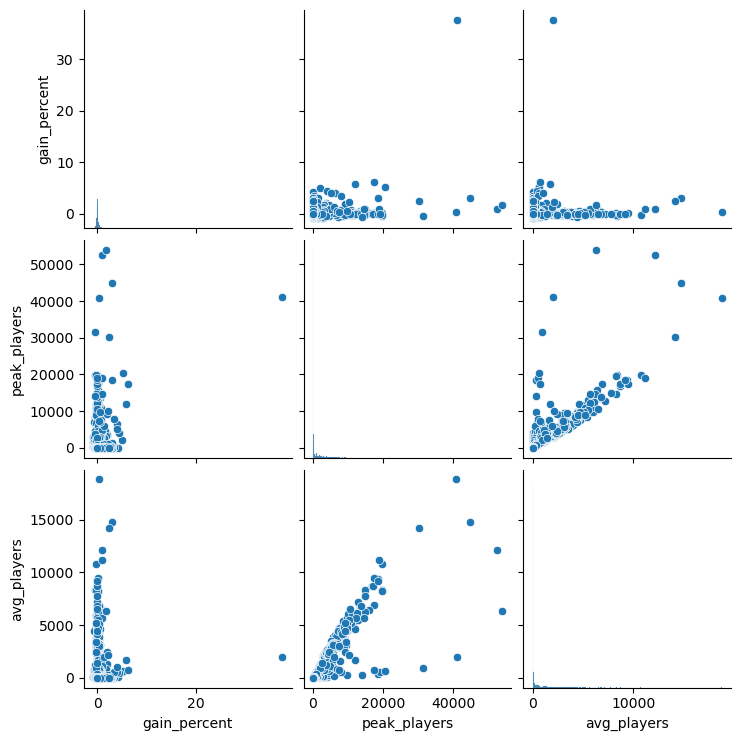

In [5]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION
#Separating df_clean into Categorical and Numerical Columns
cat_df = df_clean[['name','steam_appid','month']] #Categorical columns of our main df. Name/Steam_AppID categorize what game, and month categorizes the month the entry refers to.
num_df = df_clean[['gain_percent', 'peak_players', 'avg_players']] #Numerical columns of our main df

#Grabbing the 20 game names with most logged data
games = df_clean['name'].value_counts().head(20).index

#New Datafram containing only the Top 20 most documented games
df_top20 = df_clean[df_clean['name'].isin(games)]

#Separating df_top20 columns into Categorical and Numerical
cat_df_20 = df_top20[['name','steam_appid','month']] #Categorical columns of df_top20. Name/Steam_AppID categorize what game, and month categorizes the month the entry refers to.
num_df_20 = df_top20[['gain_percent', 'peak_players', 'avg_players']] #Numerical columns of df_top20

#print(df_top20.shape)

#-----------PLOTS-----------
#The following commented out lines are plots that we could potentially use. (Do take note of the pairplot).

#boxplot = sns.boxplot(data = df_top20)

#percent_plot = sns.scatterplot(data = df_top20['gain_percent'])

#avg_players_barplot = sns.barplot(data = df_top20, x='name', y='avg_players')
#peak_players_barplot = sns.barplot(data = df_top20, x='name', y='peak_players')

#lineplot = sns.lineplot(data=df_top20, x='month', y='avg_players', hue='name')
#lineplot.legend(loc='upper left', bbox_to_anchor=(1.02, 1))

pairplot = sns.pairplot(data=num_df_20) #IMPORTANT: Kernel Crashes due to overflow of data entries for num_df!! (Could be something of note for the writing?)

#log_scale_histplot = sns.histplot(data=df_top20, x = 'avg_players', log_scale=True)

#df_clean['avg_players'].sort_values().head(5)
#df_clean['gain_percent'].sort_values().head(5)
#df_clean['peak_players'].sort_values().head(5)

max_avg = max(df_top20['avg_players'])
max_gain = max(df_top20['gain_percent'])
max_peak =  max(df_top20['peak_players'])

#### Section 2 of EDA if you need it  - please give it a better title than this

Some more words and stuff.  Remember notebooks work best if you interleave the code that generates a result with properly annotate figures and text that puts these results into context.

In [ ]:
## YOUR CODE HERE
## FEEL FREE TO ADD MULTIPLE CELLS PER SECTION

## Ethics

 - [X] **A.1 Informed consent**: If there are human subjects, have they given informed consent, where subjects affirmatively opt-in and have a clear understanding of the data uses to which they consent?

> We have considered this issue and since we are using publicly available datasets, there won't be any human subject and they are already given informed consent due to the dataset being public

 - [X] **A.2 Collection bias**: Have we considered sources of bias that could be introduced during data collection and survey design and taken steps to mitigate those?

> There are possible biases within the datasets we plan to use. Since the statistics that are publicly accessible come from platforms like Steam, console players or private profile players may not be represented within the data. In addition, review data can be skewed because players who leave reviews often have very strong positive or negative opinions, which may not fully represent the “average” player. To reduce these issues we will clearly acknowledge these limitations when presenting our analysis/results.

 - [X] **A.3 Limit PII exposure**: Have we considered ways to minimize exposure of personally identifiable information (PII) for example through anonymization or not collecting information that isn't relevant for analysis?

> we have considered this and will only use data that is publicly available or already anonymized so no personal data is included. We will ensure that the data we collect or analyze follows platform terms of service and standard ethical practices for data use.

 - [X] **A.4 Downstream bias mitigation**: Have we considered ways to enable testing downstream results for biased outcomes (e.g., collecting data on protected group status like race or gender)?

> Yes we have considered this and we think that we can enable testing downstream results for bias outcomes by periodically test if our model is being biased based on things like if a game is made by a AAA companies or an indie companies, things like that to ensure that our model/results apply fairly across all game when analyzing if a game is dead or not.

### B. Data Storage
 - [X] **B.1 Data security**: Do we have a plan to protect and secure data (e.g., encryption at rest and in transit, access controls on internal users and third parties, access logs, and up-to-date software)?

> Since we are using publicly available data and we will make sure that the data will be anonymized, there won't be much concern when its come to protecting and securing data since there won't be sensitive data that can do harm to our subjects that the dataset come from.

 - [X] **B.2 Right to be forgotten**: Do we have a mechanism through which an individual can request their personal information be removed?

> Since we are thinking of using public datasets, we have considered this and we think that if an individual does request us to removed their information from the datset that we are using for our research, then we will manually delete them from the dataset we are using.

 - [X] **B.3 Data retention plan**: Is there a schedule or plan to delete the data after it is no longer needed?

>Yes, we are thinking of deleting data 30 days after it is no longer needed.

### C. Analysis
 - [X] **C.1 Missing perspectives**: Have we sought to address blindspots in the analysis through engagement with relevant stakeholders (e.g., checking assumptions and discussing implications with affected communities and subject matter experts)?

> Yes, we have considered addressing blindspot in our analysis by engaging with relevant stakeholders such as the communities of these games to see whether the game that we deemed as dead is still actually very much alive and active by selecting a number of communities of game we deemed as dead or alive, and by engaging with those communities, we can see if our analysis was correct or is there any blindspot within our analysis. And if there is blindspot, we will try out best to revise our analysis to reflect that as much as possible in our final report/analysis/result.

 - [X] **C.2 Dataset bias**: Have we examined the data for possible sources of bias and taken steps to mitigate or address these biases (e.g., stereotype perpetuation, confirmation bias, imbalanced classes, or omitted confounding variables)?

> Yes, as mentions before, we believed that there is possible biases such as from review being skewed since only really positive or negative opinion will leave reviews, so we plan to mitigate this by taking the average of these review to reflect the more average player base opinion on a game. We also believed another possible bias is with our player count dataset if we are to use it, is that when a game goes on sale on steam or when it win a games award, there will be a big spike in average player count in the month, so we plan to mitigate this by taking these things into account when we do our analysis.

 - [X] **C.3 Honest representation**: Are our visualizations, summary statistics, and reports designed to honestly represent the underlying data?

> We have considered this and believed that we can ensured that our visualization/summary statistics/report honestly represent our underlying dataset by making sure we don't manipulated our data to make our visualization fit what we want and instead let it be and only make our visualization easier to understand for the reader. The same apply for our summary statistics and report.

 - [X] **C.4 Privacy in analysis**: Have we ensured that data with PII are not used or displayed unless necessary for the analysis?

> We have considered this and to ensured this, we will only use anonymized and public data as well as not display any data with PII unless absolutely necessary for the analysis which we think is not necessary at all, and that the anonymized data is all we will need for our analysis hence we can minimized any privacy issues in our analysis.

 - [X] **C.5 Auditability**: Is the process of generating the analysis well documented and reproducible if we discover issues in the future?

> We have considered this and we plan to make sure that our analysis is well documented and reproducible in the future by doing things like keeping our raw dataset as csv files to keep them clean and untouch and only do our analysis with the data with a copy of the raw dataset we use. We will also make sure to script all of our steps like data cleaning, modeling, etc. And since we are using github that will also give us version control which will make it more well documented.

### D. Modeling
 - [X] **D.1 Proxy discrimination**: Have we ensured that the model does not rely on variables or proxies for variables that are unfairly discriminatory?

> Yes, we have considered this because since we using things like average player count or positive/negative review, our variables shouldn't be unfairly discriminatory, since if anything there could be bias in them, but as we have said earlier that we will take steps to mitigate these biases, we think we will be good.

 - [] **D.2 Fairness across groups**: Have we tested model results for fairness with respect to different affected groups (e.g., tested for disparate error rates)?

 - [X] **D.3 Metric selection**: Have we considered the effects of optimizing for our defined metrics and considered additional metrics?

> Yes, we have considered this, and to ensure that no bias or unintended issue will come from this, we won't be optimizing our defeined metrics and will have many additional metrics when considering answering our question to keep it as unbias and fair as possible.

 - [X] **D.4 Explainability**: Can we explain in understandable terms a decision the model made in cases where a justification is needed?

> Yes, we have considered this and we think and we can keep it understandable by making sure that in our final report, we can explain why exactly our model made certain decision if a justification is needed, and to make sure to note in our report why our models make the decisions it did to make it easier to understand for our readers.

 - [X] **D.5 Communicate limitations**: Have we communicated the shortcomings, limitations, and biases of the model to relevant stakeholders in ways that can be generally understood?

> Yes, we have considered this and we will ensured that we will communicate any shortcomings/limitations/biases of our mode to the relevant stakeholders in a way they can understand in our final report. Such as noting our biases that we might come across in our dataset/model or maybe noting that labeling a game as “dead” based only on numerical trends could overlook players who still actively enjoy the game. Because of this, we will frame our results as indicators of engagement decline rather than definitive judgments about a game's value or community.

### E. Deployment
 - [X] **E.1 Monitoring and evaluation**: Do we have a clear plan to monitor the model and its impacts after it is deployed (e.g., performance monitoring, regular audit of sample predictions, human review of high-stakes decisions, reviewing downstream impacts of errors or low-confidence decisions, testing for concept drift)?

> We plan to monitor our model and its impacts after it is deployed by checking its performance, especially if the results are the same with different datasets, as well as seeing if our model results truly reflect that to the same as the communities of games that it is analyzing.

 - [X] **E.2 Redress**: Have we discussed with our organization a plan for response if users are harmed by the results (e.g., how does the data science team evaluate these cases and update analysis and models to prevent future harm)?

> Yes, we have considered this and think that our response for if users are harmed because of the results of our model, we will pull back of model and update our analysis and model with different dataset and analyzed what is causing the harm so we can update our analysis/model to prevent future harm.

 - [X] **E.3 Roll back**: Is there a way to turn off or roll back the model in production if necessary?

> Yes, we think that we can just pull back the model if necessary.

 - [X] **E.4 Unintended use**: Have we taken steps to identify and prevent unintended uses and abuse of the model and do we have a plan to monitor these once the model is deployed?

> Yes, we think that by making sure that our model is made specifically for just analysis whether a game is dead, we can minimized any unintended usage and abuse of our model. And we plan to minotor these usage once our model is deployed by keeping track of who can get access to our model and check with them on what they are using our model for.

## Team Expectations 

Instructions: REPLACE the contents of this cell with your work, including any updates to recover points lost in your proposal feedback

## Project Timeline Proposal

Instructions: Replace this with your timeline.  **PLEASE UPDATE your Timeline!** No battle plan survives contact with the enemy, so make sure we understand how your plans have changed.  Also if you have lost points on the previous checkpoint fix them